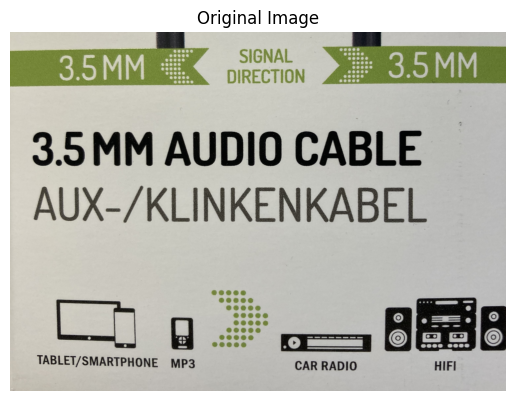

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread(r"C:\Users\Onur\openCV_IMG_process\colorRegionApp\CableLabelRGB.bmp")


img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)


plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

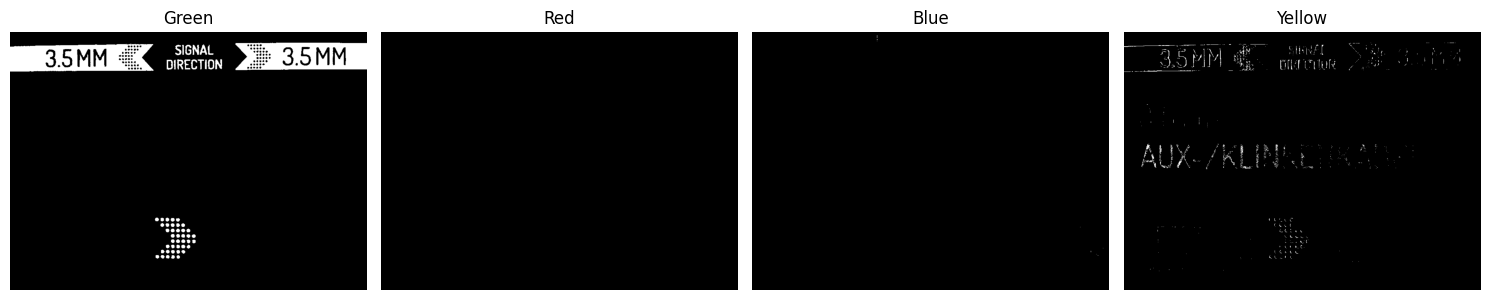

In [2]:
# Convert to HSV
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Define color ranges (HSV)
colors = {
    "Green": ([35, 50, 50], [85, 255, 255]),
    "Red": ([0, 50, 50], [10, 255, 255]),
    "Blue": ([100, 50, 50], [130, 255, 255]),
    "Yellow": ([20, 50, 50], [35, 255, 255]),
}

fig, axes = plt.subplots(1, len(colors), figsize=(15, 5))

for ax, (color_name, (lower, upper)) in zip(axes, colors.items()):
    lower = np.array(lower)
    upper = np.array(upper)
    mask = cv2.inRange(img_hsv, lower, upper)
    ax.imshow(mask, cmap='gray')
    ax.set_title(color_name)
    ax.axis('off')

plt.tight_layout()
plt.show()

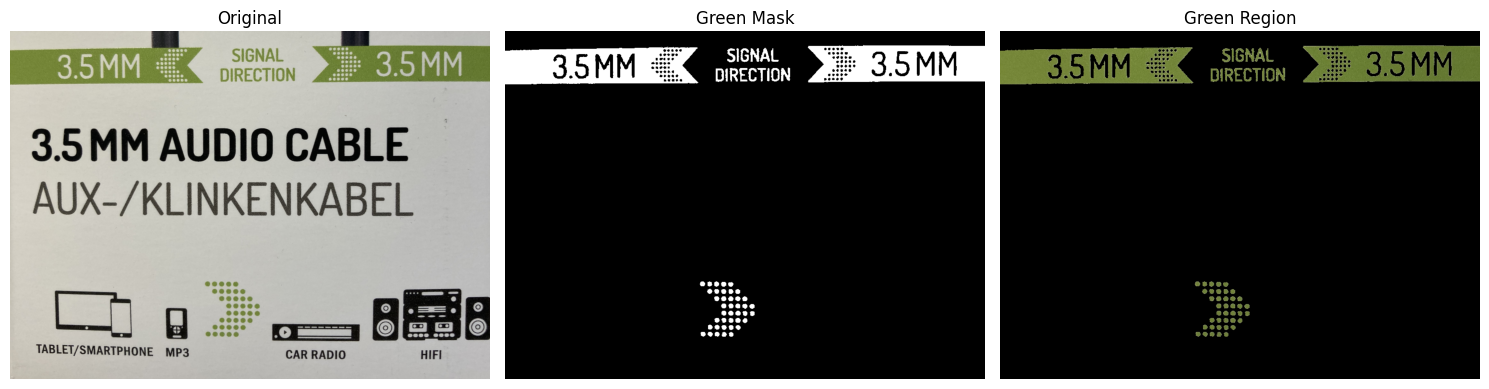

In [3]:
# Create green mask
lower_green = np.array([35, 50, 50])
upper_green = np.array([85, 255, 255])
mask_green = cv2.inRange(img_hsv, lower_green, upper_green)

# Apply mask to original image (color region)
green_region = cv2.bitwise_and(img, img, mask=mask_green)
green_region_rgb = cv2.cvtColor(green_region, cv2.COLOR_BGR2RGB)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mask_green, cmap='gray')
axes[1].set_title("Green Mask")
axes[1].axis('off')

axes[2].imshow(green_region_rgb)
axes[2].set_title("Green Region")
axes[2].axis('off')

plt.tight_layout()
plt.show()

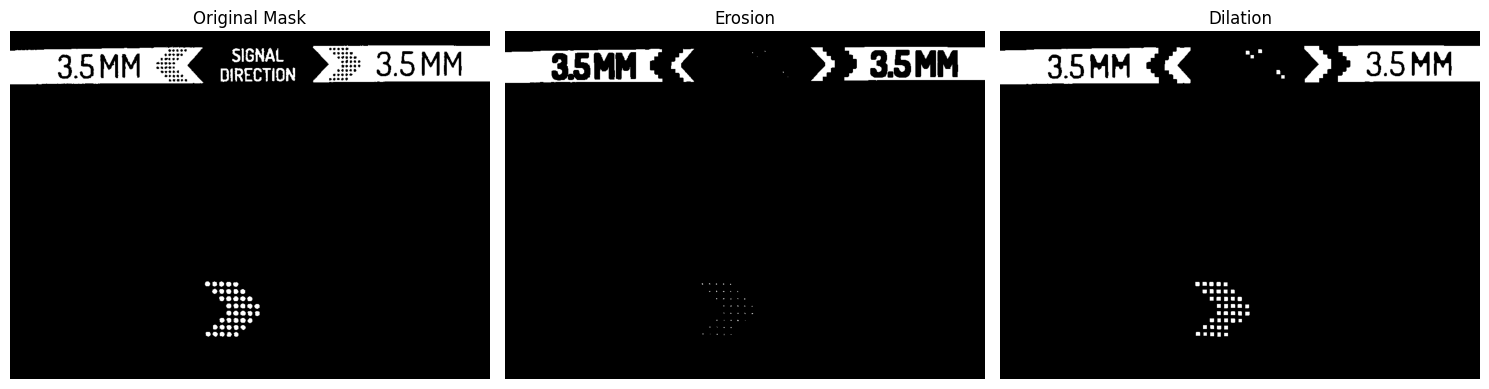

In [4]:
# 7x7 kernel (for erosion and dilation)
kernel = np.ones((7, 7), np.uint8)

# Erosion - clean noise
erosion = cv2.erode(mask_green, kernel, iterations=1)

# Dilation - restore shape
dilation = cv2.dilate(erosion, kernel, iterations=1)

# Display
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mask_green, cmap='gray')
axes[0].set_title("Original Mask")
axes[0].axis('off')

axes[1].imshow(erosion, cmap='gray')
axes[1].set_title("Erosion")
axes[1].axis('off')

axes[2].imshow(dilation, cmap='gray')
axes[2].set_title("Dilation")
axes[2].axis('off')

plt.tight_layout()
plt.show()